
# Détection de faux billets 

In [1]:

import pandas as pd
import numpy as np
from pathlib import Path

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, silhouette_score

from joblib import dump

import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)


## 1) Chargement des données

In [2]:

data_path = Path('./billets.csv')
if not data_path.exists():
    data_path = Path('/mnt/data/billets.csv')
df = pd.read_csv(data_path, sep=';')
df['is_genuine'] = df['is_genuine'].astype(int)  # 1 = vrai, 0 = faux
df.head()


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,1,171.81,104.86,104.95,4.52,2.89,112.83
1,1,171.46,103.36,103.66,3.77,2.99,113.09
2,1,172.69,104.48,103.50,4.40,2.94,113.16
3,1,171.36,103.91,103.94,3.62,3.01,113.51
4,1,171.73,104.28,103.46,4.04,3.48,112.54



## 2) Comparatif **vrais vs faux** billets

On compare la distribution des **6 variables géométriques** selon `is_genuine` :  
- statistiques par groupe,  
- histogrammes superposés,  
- boxplots,  
- corrélations,  
- variables les plus **discriminantes** (écart standardisé / *Cohen's d*).


In [3]:

feature_cols = ['length','height_left','height_right','margin_up','margin_low','diagonal']

# Comptage
print("Répartition vraie/faux :")
print(df['is_genuine'].value_counts())

# Statistiques par groupe
group_stats = df.groupby('is_genuine')[feature_cols].agg(['mean','std','min','max','median'])
group_stats


Répartition vraie/faux :
is_genuine
1    1000
0     500
Name: count, dtype: int64


length                                    height_left  \
                 mean       std     min     max   median        mean   
is_genuine                                                             
0           111.63064  0.615543  109.49  113.85  111.630   104.19034   
1           113.20243  0.359552  111.76  114.44  113.205   103.94913   

                                             height_right                    \
                 std     min     max  median         mean       std     min   
is_genuine                                                                    
0           0.223758  103.51  104.88  104.18    104.14362  0.270878  103.43   
1           0.300231  103.14  104.86  103.95    103.80865  0.291570  102.82   

                           margin_up                              margin_low  \
               max  median      mean       std   min   max median       mean   
is_genuine                                                                     
0           104.95  104.16   3.35016  0.180498  2.92  3.91   3.35   5.215935   
1           104.95  103.81   3.05213  0.186340  2.27  3.74   3.05   4.116097   

                                          diagonal                            \
                 std   min   max median       mean       std     min     max   
is_genuine                                                                     
0           0.553531  3.82  6.90   5.19  171.90116  0.306861  171.04  173.01   
1           0.319124  2.98  5.04   4.11  171.98708  0.300441  171.04  172.92   

                    
            median  
is_genuine          
0           171.91  
1           171.99

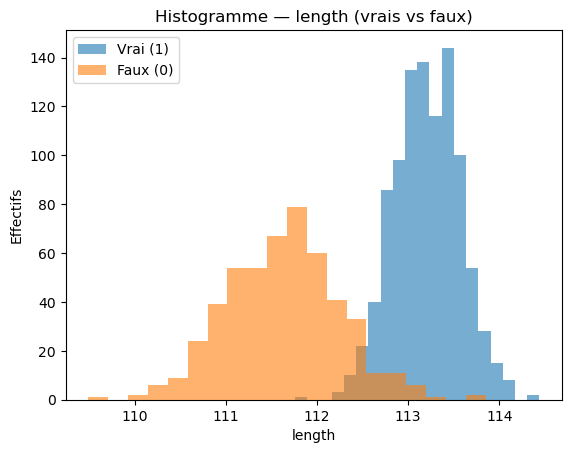

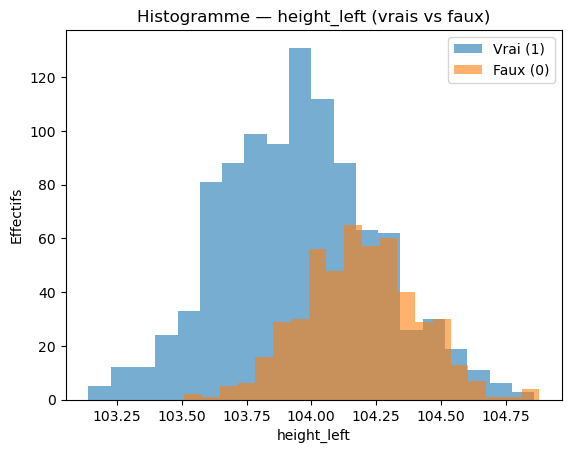

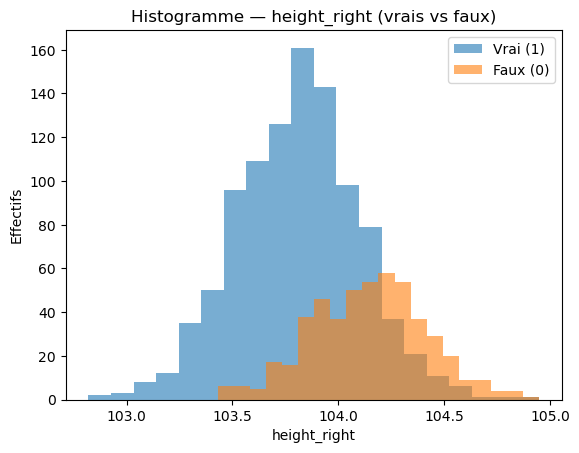

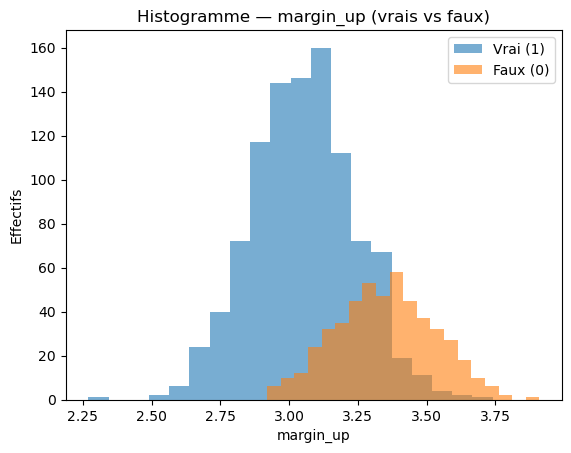

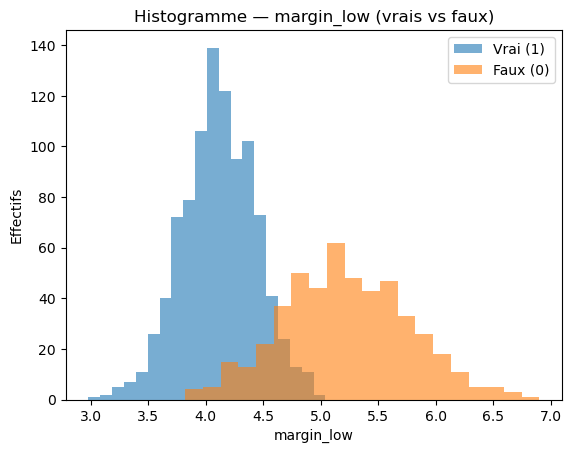

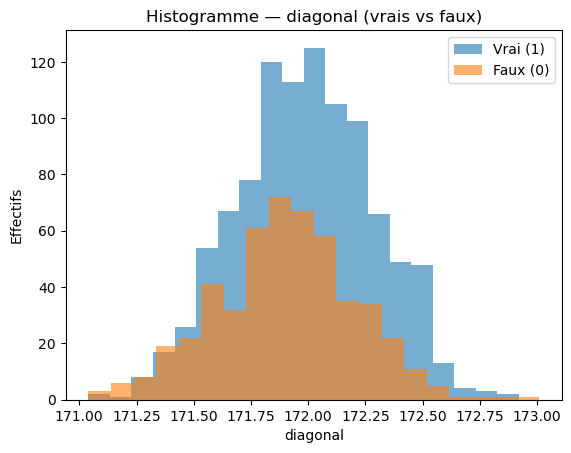

In [4]:

# Histogrammes superposés
true_df = df[df['is_genuine']==1]
false_df = df[df['is_genuine']==0]

for col in feature_cols:
    plt.figure()
    plt.hist(true_df[col].dropna(), bins=20, alpha=0.6, label='Vrai (1)')
    plt.hist(false_df[col].dropna(), bins=20, alpha=0.6, label='Faux (0)')
    plt.title(f"Histogramme — {col} (vrais vs faux)")
    plt.xlabel(col); plt.ylabel("Effectifs")
    plt.legend()
    plt.show()


C:\Users\kemid\AppData\Local\Temp\ipykernel_52132\2999587597.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([false_df[col].dropna(), true_df[col].dropna()], labels=['Faux (0)','Vrai (1)'])


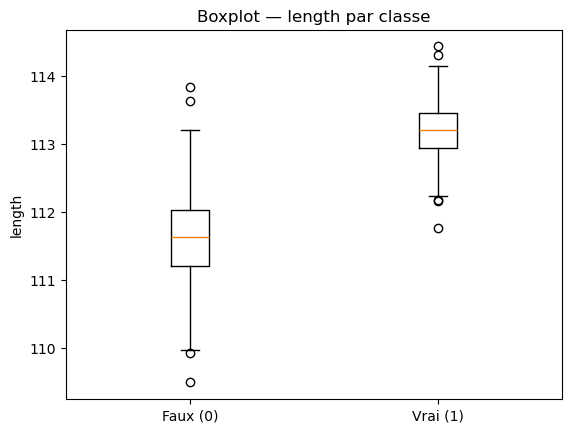

C:\Users\kemid\AppData\Local\Temp\ipykernel_52132\2999587597.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([false_df[col].dropna(), true_df[col].dropna()], labels=['Faux (0)','Vrai (1)'])


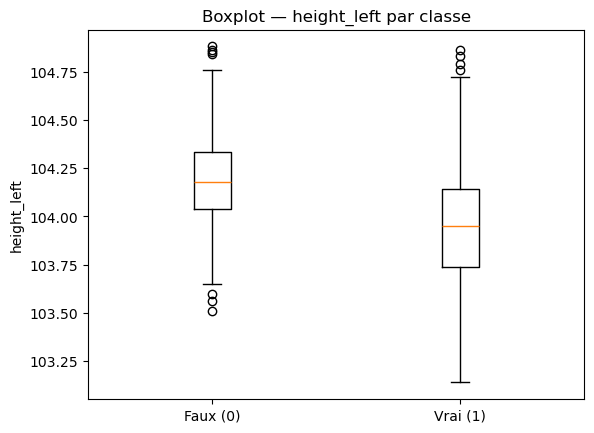

C:\Users\kemid\AppData\Local\Temp\ipykernel_52132\2999587597.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([false_df[col].dropna(), true_df[col].dropna()], labels=['Faux (0)','Vrai (1)'])


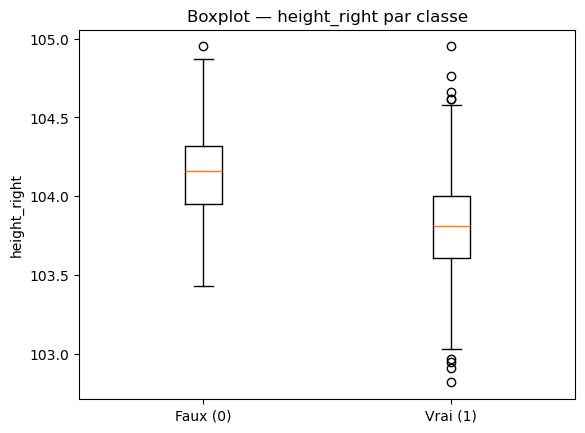

C:\Users\kemid\AppData\Local\Temp\ipykernel_52132\2999587597.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([false_df[col].dropna(), true_df[col].dropna()], labels=['Faux (0)','Vrai (1)'])


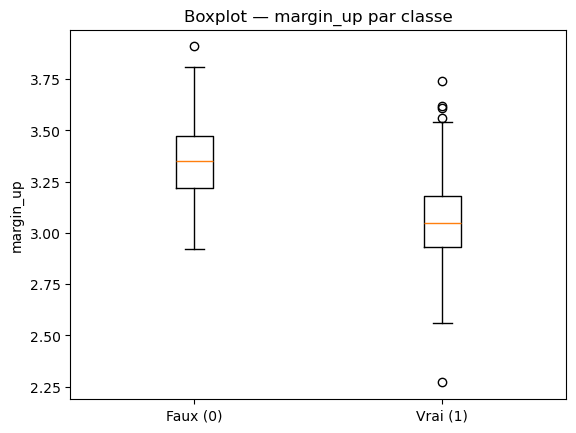

C:\Users\kemid\AppData\Local\Temp\ipykernel_52132\2999587597.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([false_df[col].dropna(), true_df[col].dropna()], labels=['Faux (0)','Vrai (1)'])


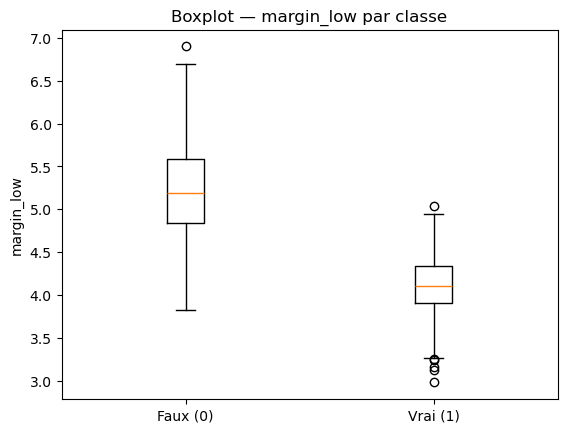

C:\Users\kemid\AppData\Local\Temp\ipykernel_52132\2999587597.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([false_df[col].dropna(), true_df[col].dropna()], labels=['Faux (0)','Vrai (1)'])


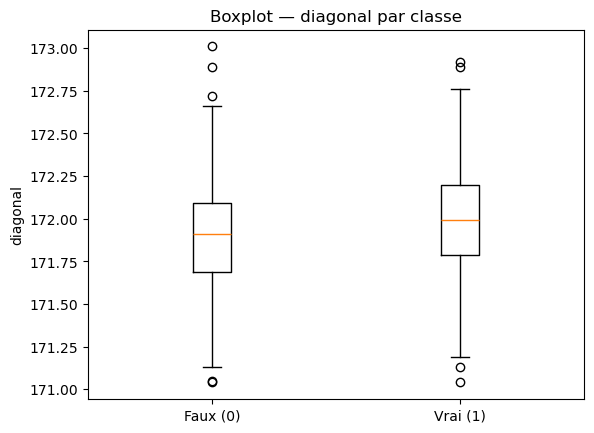

In [5]:

# Boxplots par variable
for col in feature_cols:
    plt.figure()
    plt.boxplot([false_df[col].dropna(), true_df[col].dropna()], labels=['Faux (0)','Vrai (1)'])
    plt.title(f"Boxplot — {col} par classe")
    plt.ylabel(col)
    plt.show()


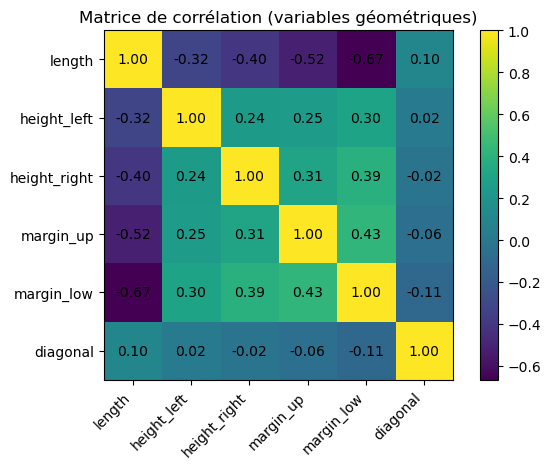

,length,height_left,height_right,margin_up,margin_low,diagonal
length,1.000000,-0.320863,-0.401751,-0.520575,-0.666753,0.097587
height_left,-0.320863,1.000000,0.242279,0.246522,0.302643,0.019472
height_right,-0.401751,0.242279,1.000000,0.307005,0.391085,-0.024492
margin_up,-0.520575,0.246522,0.307005,1.000000,0.431606,-0.055649
margin_low,-0.666753,0.302643,0.391085,0.431606,1.000000,-0.111534
diagonal,0.097587,0.019472,-0.024492,-0.055649,-0.111534,1.000000


In [6]:

# Matrice de corrélation (toutes classes confondues)
corr = df[feature_cols].corr()
plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.title("Matrice de corrélation (variables géométriques)")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha='right')
plt.yticks(range(len(feature_cols)), feature_cols)
for (i,j), v in np.ndenumerate(corr.values):
    plt.text(j, i, f"{v:.2f}", ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.show()
corr


In [7]:

# Variables les plus discriminantes (Cohen's d)
def cohens_d(a, b):
    a = np.array(a.dropna())
    b = np.array(b.dropna())
    na, nb = len(a), len(b)
    sa, sb = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((na-1)*sa**2 + (nb-1)*sb**2) / (na+nb-2))
    if sp == 0:
        return 0.0
    return (a.mean() - b.mean()) / sp

disc = []
for col in feature_cols:
    d = cohens_d(true_df[col], false_df[col])
    disc.append((col, abs(d), d))
disc_df = pd.DataFrame(disc, columns=['variable','|cohen_d|','signed_d']).sort_values('|cohen_d|', ascending=False)
disc_df


,variable,|cohen_d|,signed_d
0,length,3.410273,3.410273
4,margin_low,2.662916,-2.662916
3,margin_up,1.616089,-1.616089
2,height_right,1.175977,-1.175977
1,height_left,0.870445,-0.870445
5,diagonal,0.283944,0.283944


## 3) Imputation par **régression linéaire** de `margin_low` + tests d’hypothèses

                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     266.1
Date:                Thu, 11 Sep 2025   Prob (F-statistic):          2.60e-202
Time:                        16:01:19   Log-Likelihood:                -1001.3
No. Observations:                1463   AIC:                             2015.
Df Residuals:                    1457   BIC:                             2046.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           22.9948      9.656      2.382   

,feature,VIF
0,const,590198.238883
1,length,1.576950
2,height_left,1.138261
3,height_right,1.230115
4,margin_up,1.404404
5,diagonal,1.013613


Breusch-Pagan p-value: 7.759535216111738e-16
Jarque-Bera p-value: 1.5271011111344769e-21


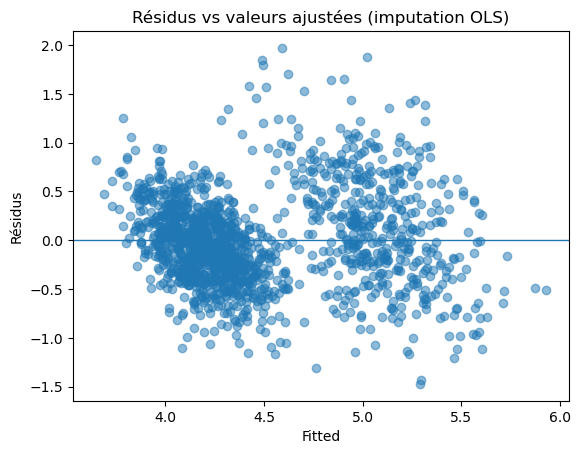

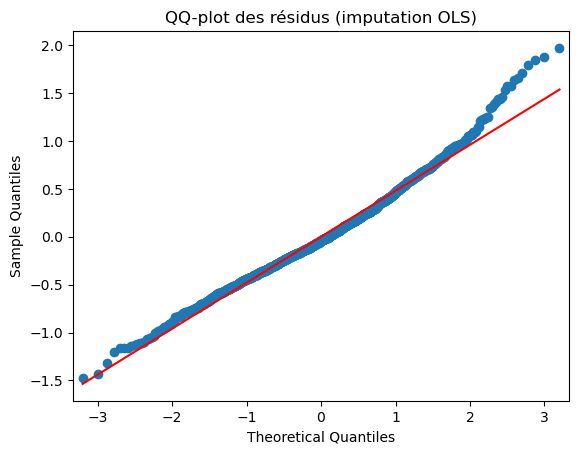

In [8]:

features_for_impute = ['length','height_left','height_right','margin_up','diagonal']
df_train_impute = df.dropna(subset=['margin_low']).copy()
X_imp = df_train_impute[features_for_impute]
y_imp = df_train_impute['margin_low']

X_imp_const = sm.add_constant(X_imp)
ols_model = sm.OLS(y_imp, X_imp_const).fit()
print(ols_model.summary())

vif_df = pd.DataFrame({
    "feature": ['const'] + features_for_impute,
    "VIF": [variance_inflation_factor(X_imp_const.values, i) for i in range(X_imp_const.shape[1])]
})
display(vif_df)

bp_stat, bp_pvalue, _, _ = het_breuschpagan(ols_model.resid, X_imp_const)
print("Breusch-Pagan p-value:", bp_pvalue)

jb_stat, jb_pvalue, _, _ = jarque_bera(ols_model.resid)
print("Jarque-Bera p-value:", jb_pvalue)

fitted = ols_model.fittedvalues
resid = ols_model.resid

plt.figure()
plt.scatter(fitted, resid, alpha=0.5)
plt.axhline(0, linewidth=1)
plt.title("Résidus vs valeurs ajustées (imputation OLS)")
plt.xlabel("Fitted"); plt.ylabel("Résidus")
plt.show()

sm.qqplot(resid, line='s')
plt.title("QQ-plot des résidus (imputation OLS)")
plt.show()

#df_missing = df[df['margin_low'].isna()].copy()
#if not df_missing.empty:
#    X_miss = sm.add_constant(df_missing[features_for_impute])
#    df.loc[df['margin_low'].isna(), 'margin_low'] = ols_model.predict(X_miss)


In [9]:
n_total = len(df)
n_na = df['margin_low'].isna().sum()
print(f"Total lignes : {n_total}")
print(f"NA sur margin_low : {n_na}")


Total lignes : 1500
NA sur margin_low : 37


In [10]:
df = df.dropna(subset=['margin_low']).reset_index(drop=True)
print("Shape après suppression :", df.shape)


Shape après suppression : (1463, 7)


## 4) Split train/test (80/20 stratifié)

In [11]:

feature_cols = ['length','height_left','height_right','margin_up','margin_low','diagonal']
X = df[feature_cols].copy()
y = df['is_genuine'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((1170, 6), (293, 6), 0.6641025641025641, 0.6621160409556314)

## 5) ACP (standardisation → PCA)

Variance expliquée: [0.43207529 0.16827638] | cumul = 0.6003516714404704


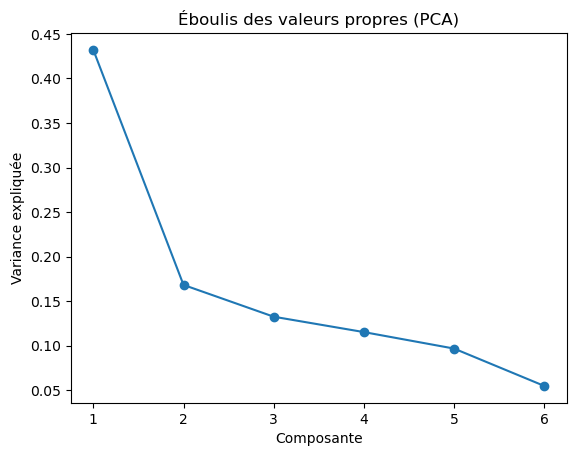

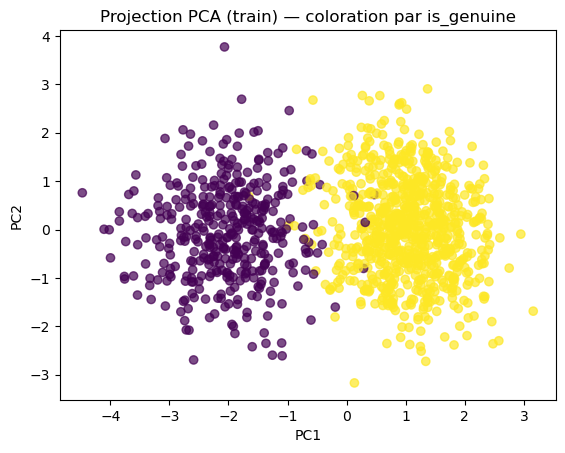

In [12]:

scaler_for_pca = StandardScaler()
X_train_scaled_for_pca = scaler_for_pca.fit_transform(X_train)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled_for_pca)
print("Variance expliquée:", pca.explained_variance_ratio_, "| cumul =", pca.explained_variance_ratio_.sum())

pca_full = PCA().fit(X_train_scaled_for_pca)
plt.figure()
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_, marker='o')
plt.title("Éboulis des valeurs propres (PCA)")
plt.xlabel("Composante"); plt.ylabel("Variance expliquée")
plt.show()

plt.figure()
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, alpha=0.7)
plt.title("Projection PCA (train) — coloration par is_genuine")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


## 6) Fonctions utilitaires

In [13]:

def evaluate_binary(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {"accuracy":acc,"precision":prec,"recall":rec,"f1":f1,"confusion_matrix":cm}

def show_cm(cm, title="Matrice de confusion"):
    fig = plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title); plt.xlabel("Prédits"); plt.ylabel("Réels")
    for (i,j), z in np.ndenumerate(cm):
        plt.text(j, i, str(z), ha='center', va='center')
    plt.show()


## 7) Non supervisé — K‑Means (choix de k)

C:\Users\kemid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\kemid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\kemid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\kemid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

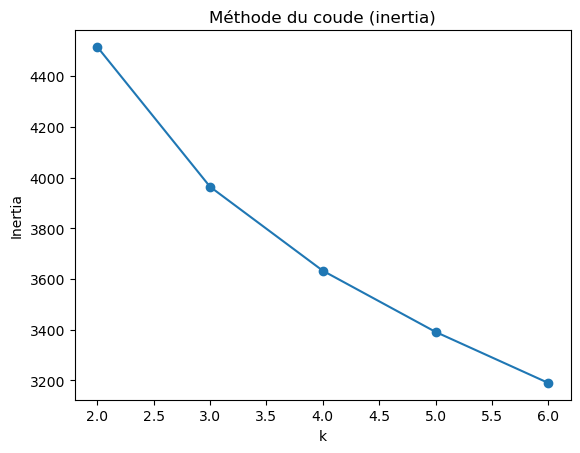

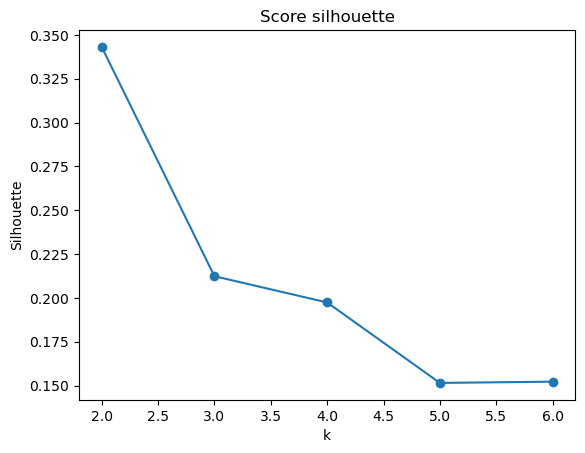

k optimal (silhouette) = 2
Mapping clusters→classes: {0: 1, 1: 0}


C:\Users\kemid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [14]:
# Standardisation pour K-means
scaler_km = StandardScaler()
Xtr_km = scaler_km.fit_transform(X_train)
Xte_km = scaler_km.transform(X_test)

# Choix de k (coude + silhouette)
Ks = range(2, 7)
inertias, silhouettes = [], []
for k in Ks:
    km_tmp = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xtr_km)
    inertias.append(km_tmp.inertia_)
    silhouettes.append(silhouette_score(Xtr_km, km_tmp.labels_))

plt.figure()
plt.plot(list(Ks), inertias, marker='o')
plt.title("Méthode du coude (inertia)"); plt.xlabel("k"); plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(list(Ks), silhouettes, marker='o')
plt.title("Score silhouette"); plt.xlabel("k"); plt.ylabel("Silhouette")
plt.show()

best_k = Ks[int(np.argmax(silhouettes))]
print("k optimal (silhouette) =", best_k)

# Entraînement final
kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE).fit(Xtr_km)

# Mapping cluster -> classe (majorité sur TRAIN)
train_clusters = kmeans.predict(Xtr_km)
map_dict = {cl: int(y_train[train_clusters == cl].mode()[0]) for cl in np.unique(train_clusters)}
print("Mapping clusters→classes:", map_dict)


In [15]:
centroids_original = pd.DataFrame(
    scaler_km.inverse_transform(kmeans.cluster_centers_),
    columns=feature_cols,
    index=[f"cluster_{i}" for i in range(best_k)]
)
centroids_original



,length,height_left,height_right,margin_up,margin_low,diagonal
cluster_0,113.197841,103.951170,103.804679,3.055501,4.123869,171.994165
cluster_1,111.647781,104.205969,104.158010,3.358418,5.218878,171.909413


{'accuracy': 0.9795221843003413, 'precision': 0.9747474747474747, 'recall': 0.9948453608247423, 'f1': 0.9846938775510204, 'confusion_matrix': array([[ 94,   5],
       [  1, 193]], dtype=int64)}


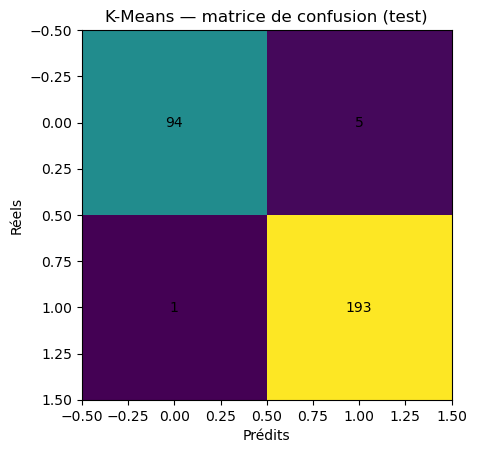

In [16]:
test_clusters = kmeans.predict(Xte_km)
y_pred_km = np.vectorize(map_dict.get)(test_clusters)

metrics_km = evaluate_binary(y_test, y_pred_km)
print(metrics_km)
show_cm(metrics_km["confusion_matrix"], "K-Means — matrice de confusion (test)")


## 8) Supervisé — Régression logistique (+ CV)

CV F1 mean±std: 0.9941996251403016 0.005190435589812831
CV Acc mean±std: 0.9923076923076923 0.006837606837606858
{'accuracy': 0.9897610921501706, 'precision': 0.9847715736040609, 'recall': 1.0, 'f1': 0.9923273657289002, 'confusion_matrix': array([[ 96,   3],
       [  0, 194]], dtype=int64)}


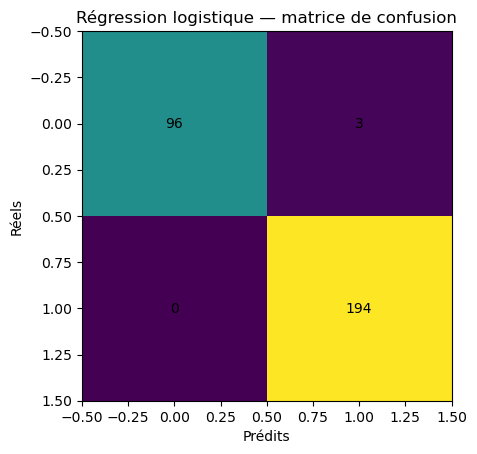

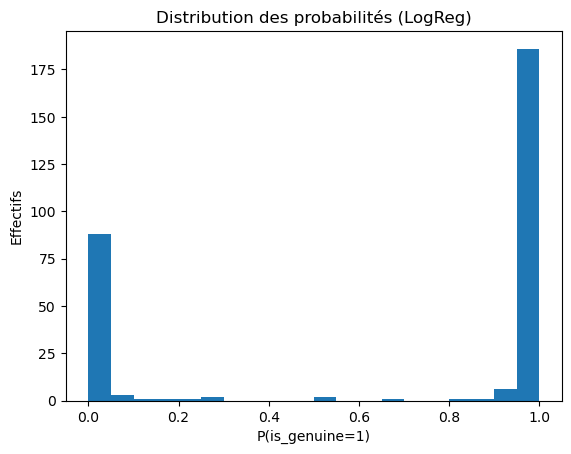

In [17]:

logreg_pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1 = cross_val_score(logreg_pipe, X_train, y_train, cv=cv, scoring='f1')
cv_acc = cross_val_score(logreg_pipe, X_train, y_train, cv=cv, scoring='accuracy')
print("CV F1 mean±std:", cv_f1.mean(), cv_f1.std())
print("CV Acc mean±std:", cv_acc.mean(), cv_acc.std())

logreg_pipe.fit(X_train, y_train)
y_pred_log = logreg_pipe.predict(X_test)
metrics_log = evaluate_binary(y_test, y_pred_log)
print(metrics_log)
show_cm(metrics_log['confusion_matrix'], "Régression logistique — matrice de confusion")

proba_log = logreg_pipe.predict_proba(X_test)[:,1]
plt.figure()
plt.hist(proba_log, bins=20)
plt.title("Distribution des probabilités (LogReg)")
plt.xlabel("P(is_genuine=1)"); plt.ylabel("Effectifs")
plt.show()


## 9) KNN (recherche du meilleur k)

Meilleur k: {'clf__n_neighbors': 9}
{'accuracy': 0.9863481228668942, 'precision': 0.9797979797979798, 'recall': 1.0, 'f1': 0.9897959183673469, 'confusion_matrix': array([[ 95,   4],
       [  0, 194]], dtype=int64)}


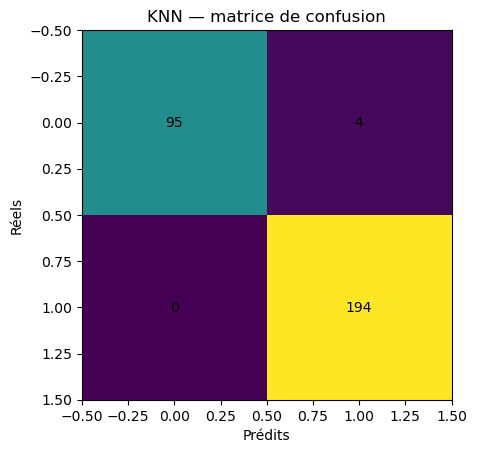

In [18]:

knn_pipe = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])
grid_knn = GridSearchCV(knn_pipe, {'clf__n_neighbors':[3,5,7,9,11]}, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train, y_train)
print("Meilleur k:", grid_knn.best_params_)
y_pred_knn = grid_knn.predict(X_test)
metrics_knn = evaluate_binary(y_test, y_pred_knn)
print(metrics_knn)
show_cm(metrics_knn['confusion_matrix'], "KNN — matrice de confusion")


## 10) Random Forest

{'accuracy': 0.9897610921501706, 'precision': 0.9847715736040609, 'recall': 1.0, 'f1': 0.9923273657289002, 'confusion_matrix': array([[ 96,   3],
       [  0, 194]], dtype=int64)}


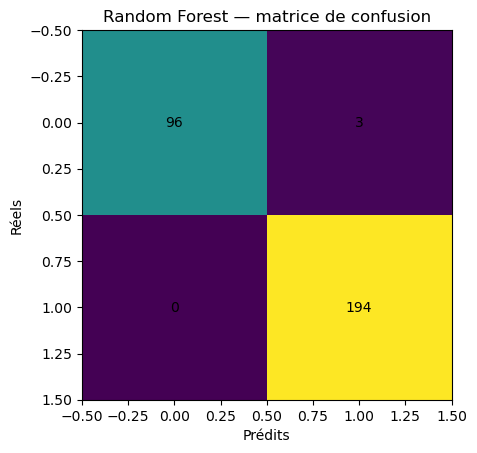

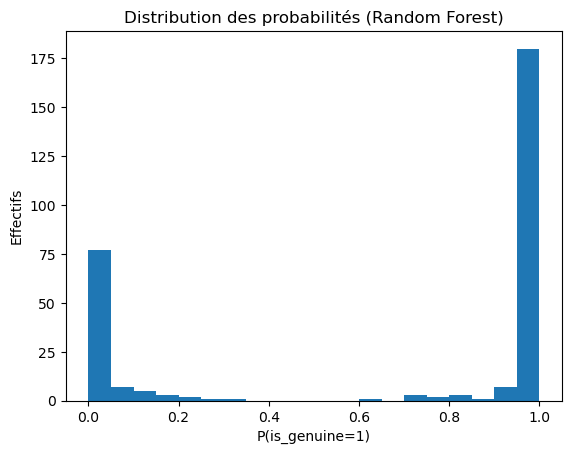

In [19]:

rf = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
metrics_rf = evaluate_binary(y_test, y_pred_rf)
print(metrics_rf)
show_cm(metrics_rf['confusion_matrix'], "Random Forest — matrice de confusion")

proba_rf = rf.predict_proba(X_test)[:,1]
plt.figure()
plt.hist(proba_rf, bins=20)
plt.title("Distribution des probabilités (Random Forest)")
plt.xlabel("P(is_genuine=1)"); plt.ylabel("Effectifs")
plt.show()


## 11) Comparaison & sélection du modèle final

In [20]:

results = pd.DataFrame([
    {"model":"KMeans", **{k:v for k,v in metrics_km.items() if k!='confusion_matrix'}},
    {"model":"LogisticRegression", **{k:v for k,v in metrics_log.items() if k!='confusion_matrix'}},
    {"model":"KNN(best)", **{k:v for k,v in metrics_knn.items() if k!='confusion_matrix'}},
    {"model":"RandomForest", **{k:v for k,v in metrics_rf.items() if k!='confusion_matrix'}},
]).set_index("model").sort_values("f1", ascending=False)
display(results)

best_model_name = results.sort_values(["f1","accuracy"], ascending=False).index[0]
print("Modèle sélectionné:", best_model_name)


,accuracy,precision,recall,f1
model,,,,
LogisticRegression,0.989761,0.984772,1.000000,0.992327
RandomForest,0.989761,0.984772,1.000000,0.992327
KNN(best),0.986348,0.979798,1.000000,0.989796
KMeans,0.979522,0.974747,0.994845,0.984694


Modèle sélectionné: LogisticRegression


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])


In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_res = cross_validate(
    final_pipe, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1
)

print("Validation croisée 5-fold — moyenne ± écart-type")
for m in scoring:
    vals = cv_res[f'test_{m}']
    print(f"{m:9s}: {vals.mean():.4f} ± {vals.std():.4f}")


Validation croisée 5-fold — moyenne ± écart-type
accuracy : 0.9923 ± 0.0068
precision: 0.9923 ± 0.0026
recall   : 0.9961 ± 0.0077
f1       : 0.9942 ± 0.0052


{'accuracy': 0.9897610921501706, 'precision': 0.9847715736040609, 'recall': 1.0, 'f1': 0.9923273657289002, 'confusion_matrix': array([[ 96,   3],
       [  0, 194]], dtype=int64)}


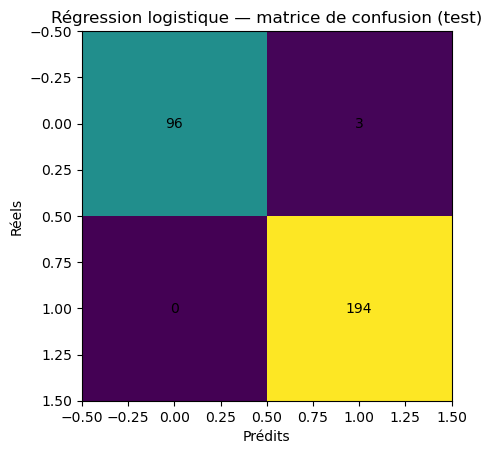

In [33]:
# Entraîne sur TOUT le train
final_pipe.fit(X_train, y_train)

# Prédiction sur le test
y_pred_test = final_pipe.predict(X_test)

# Tes utilitaires (si tu les as déjà définis plus haut)
metrics_final = evaluate_binary(y_test, y_pred_test)
print(metrics_final)
show_cm(metrics_final['confusion_matrix'], title="Régression logistique — matrice de confusion (test)")


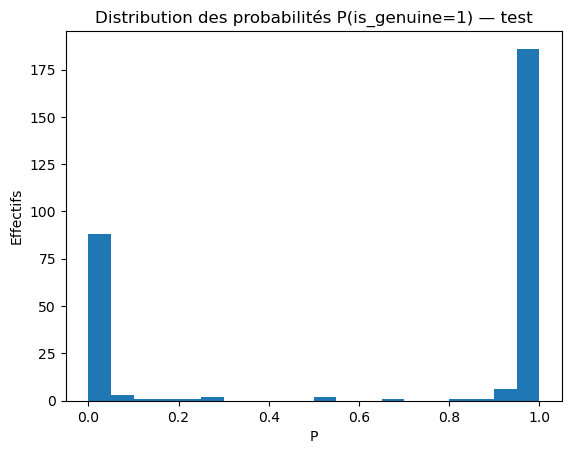

Métriques avec seuil 0.4:
{'accuracy': 0.9897610921501706, 'precision': 0.9847715736040609, 'recall': 1.0, 'f1': 0.9923273657289002, 'confusion_matrix': array([[ 96,   3],
       [  0, 194]], dtype=int64)}


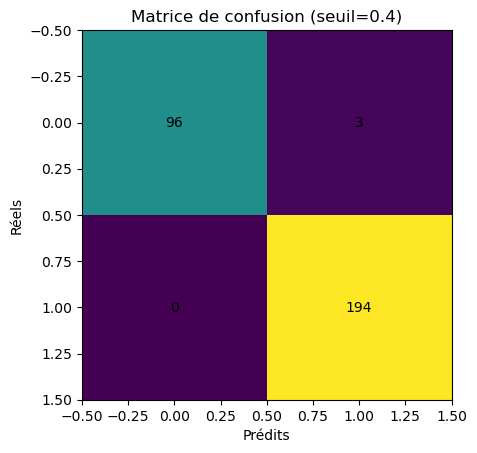

In [34]:
import matplotlib.pyplot as plt
import numpy as np

proba_test = final_pipe.predict_proba(X_test)[:, 1]

plt.figure()
plt.hist(proba_test, bins=20)
plt.title("Distribution des probabilités P(is_genuine=1) — test")
plt.xlabel("P")
plt.ylabel("Effectifs")
plt.show()

# (Optionnel) Tester un autre seuil, ex. 0.4
th = 0.40
y_pred_th = (proba_test >= th).astype(int)
metrics_th = evaluate_binary(y_test, y_pred_th)
print(f"Métriques avec seuil {th}:")
print(metrics_th)
show_cm(metrics_th['confusion_matrix'], title=f"Matrice de confusion (seuil={th})")


### Export du modèle (`model_final.joblib`) + sauvegarde des métriques

In [35]:

trained_objects = {
    "KMeans": ("kmeans", kmeans, scaler_km, map_dict),
    "LogisticRegression": ("sklearn", logreg_pipe),
    "KNN(best)": ("sklearn", grid_knn.best_estimator_),
    "RandomForest": ("sklearn", rf),
}

kind, *objs = trained_objects[best_model_name]
export = {"type":kind, "features":feature_cols}

if kind=="kmeans":
    _, km, scaler, mapping = objs
    export.update({"kmeans":km, "scaler":scaler, "mapping":mapping})
else:
    (pipe,) = objs
    export.update({"pipeline":pipe})

dump(export, Path("./model_final.joblib"))
results.to_csv("model_results.csv", index=True)
print("Export OK.")


Export OK.



---

###  Nouveau test :

-


In [36]:
# === Lecture robuste + prédiction sur billets_production.csv ===
import pandas as pd, numpy as np
from pathlib import Path
from joblib import load

In [37]:
# Charger le modèle exporté
payload = load("model_final.joblib")          # contient 'features' + pipeline OU (kmeans+scaler+mapping)
features = payload["features"]                # ex: ['length','height_left','height_right','margin_up','margin_low','diagonal']



In [38]:
def read_production(path):
    """
    Lecture robuste du CSV : détection auto du séparateur, nettoyage des noms de colonnes,
    correction de petites fautes fréquentes (heigth_left, marginup, etc.).
    """
    # 1) laisser Pandas inférer le séparateur
    df = pd.read_csv(path, sep=None, engine="python")
    # si Pandas a tout mis dans 1 colonne → réessayer avec ';' puis ','
    if df.shape[1] == 1:
        df = pd.read_csv(path, sep=';')
    if df.shape[1] == 1:
        df = pd.read_csv(path, sep=',')

    # 2) normaliser les noms de colonnes
    df.columns = [c.strip().lower().replace(' ', '_').replace('\ufeff','') for c in df.columns]

    # 3) corriger quelques variantes courantes
    ren = {
        "heigth_left":"height_left",
        "heigth_right":"height_right",
        "marginup":"margin_up",
        "marginlow":"margin_low",
        "diag":"diagonal",
        "length_":"length"
    }
    df = df.rename(columns=ren)
    return df

In [39]:
# -- Lire le fichier de prod
prod_path = Path("billets_production.csv")
if not prod_path.exists():
    prod_path = Path("/mnt/data/billets_production.csv")  # au cas où
new_sample = read_production(prod_path)

print("Colonnes lues :", list(new_sample.columns))  # debug utile

Colonnes lues : ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length', 'id']


In [40]:
# Vérifier les colonnes requises
missing = [c for c in features if c not in new_sample.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans le fichier: {missing}")


In [41]:
# Préparer X
new_predict = new_sample[features].copy()
new_predict = new_predict.fillna(new_predict.median(numeric_only=True))

In [42]:
# Prédire + probabilités
if payload.get("type") == "kmeans":
    scaler = payload["scaler"]; km = payload["kmeans"]; mapping = payload["mapping"]
    Xs = scaler.transform(new_predict)
    cl = km.predict(Xs)
    pred = np.vectorize(mapping.get)(cl)          # 1 = vrai, 0 = faux
    # proba "vrai" approximative via distances aux centroïdes
    dists = km.transform(Xs); inv = 1/(dists+1e-9)
    if 1 in mapping.values():
        idx_true = list(mapping.values()).index(1)
        proba_true = (inv / inv.sum(axis=1, keepdims=True))[:, idx_true]
    else:
        proba_true = inv.max(axis=1) / inv.sum(axis=1)
else:  # sklearn pipeline (LogReg / KNN / RF)
    pipe = payload["pipeline"]
    proba_true = pipe.predict_proba(new_predict)[:, 1]
    pred = (proba_true >= 0.5).astype(int)

In [43]:
# Résultat + comptage
out = new_sample.copy()
out["prediction"] = pred                      # 1 = vrai, 0 = faux
out["proba_is_genuine"] = proba_true
print(f"Total: {len(out)} | Vrais: {(out['prediction']==1).sum()} | Faux: {(out['prediction']==0).sum()}")

Total: 5 | Vrais: 2 | Faux: 3


In [44]:
# Aperçu
out.head(10)

,diagonal,height_left,height_right,margin_low,margin_up,length,id,prediction,proba_is_genuine
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,0,0.001813
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,0,0.000183
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,0,0.000356
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,1,0.973913
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,1,0.999839
